### Import necessary libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid")
print("Libraries imported")

Libraries imported


### Define the path to the data file

In [2]:
DATA_PATH = os.path.join('..', 'data', 'imdb.csv')
print(f"Data path set to: {DATA_PATH}")

if not os.path.exists(DATA_PATH):
    print(f"Data file not found at {DATA_PATH}. Please check the path.")
else:
    print(f"Data file found at {DATA_PATH}.")
    print("Proceeding with analysis...")

Data path set to: ../data/imdb.csv
Data file found at ../data/imdb.csv.
Proceeding with analysis...


### Load the dataset


In [3]:
try:
    df = pd.read_csv(DATA_PATH)
    print("Data loaded successfully.")
except FileNotFoundError:
    print(f"Error loading file. Please ensure '{DATA_PATH}' is correct and the file exists.")
except Exception as e:
    print(f"An error occurred while loading the data: {e}")
    df = None

Data loaded successfully.


### Initial inspection (only if df loaded successfully)

In [4]:
if df is not None:
    print("First 5 rows of the dataset:")
    display(df.head())
    print("\nDataset Information:")
    df.info()
    
    print("\nDataset Shape (rows, columns):")
    print(df.shape)
else:
    print("Cannot inspect data because loading failed.")

First 5 rows of the dataset:


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB

Dataset Shape (rows, columns):
(50000, 2)


### Check for missing values

In [5]:
if df is not None:
    print("\nMissing values per column:")
    missing_values = df.isnull().sum()
    print(missing_values)

    if missing_values.sum() == 0:
        print("No missing values in the dataset.")
    else:
        print(f"\nTotal missing values found: {missing_values.sum()}")


Missing values per column:
review       0
sentiment    0
dtype: int64
No missing values in the dataset.


### Analyze the target variable ('sentiment')


Analysis of 'sentiment' column:
Value Counts:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


/mnt/Files/Programming/Tutorials/MLOps/sentiment_hub/.venv/lib/python3.13/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/mnt/Files/Programming/Tutorials/MLOps/sentiment_hub/.venv/lib/python3.13/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


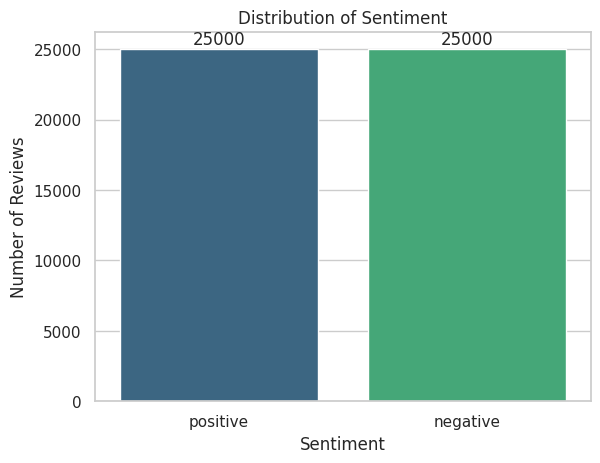


Dataset appears balanced.


In [22]:
if df is not None and "sentiment" in df.columns:
    print("\nAnalysis of 'sentiment' column:")
    sentiment_counts = df["sentiment"].value_counts()
    print("Value Counts:")
    print(sentiment_counts)

    # Plotting the distribution
    plt.Figure(figsize=(6, 4))
    sns.countplot(x="sentiment", data=df, palette="viridis", hue="sentiment")
    plt.title("Distribution of Sentiment")
    plt.xlabel("Sentiment")
    plt.ylabel("Number of Reviews")
    # Add counts on top of bars
    for index, value in enumerate(sentiment_counts):
        plt.text(index, value + 100, str(value), ha='center', va='bottom') # Adjust position
    plt.show()
    
    # Check balance
    if len(sentiment_counts) == 2:
        diff = abs(sentiment_counts.iloc[0] - sentiment_counts.iloc[1])
        total = sentiment_counts.sum()
        imbalance_ratio = diff / total
        print(f"\nDataset appears {'balanced' if imbalance_ratio < 0.1 else 'slightly imbalanced' if imbalance_ratio < 0.3 else 'imbalanced'}.")
    else:
        print("\nMore than two sentiment categories found or sentiment column missing.")
elif df is not None:
    print("\n'sentiment' column not found in the dataset.")

### Explore the 'review' column (optional, basic)


Analysis of 'review' column:
Basic statistics for review length:
count    50000.000000
mean      1309.431020
std        989.728014
min         32.000000
25%        699.000000
50%        970.000000
75%       1590.250000
max      13704.000000
Name: review_length, dtype: float64


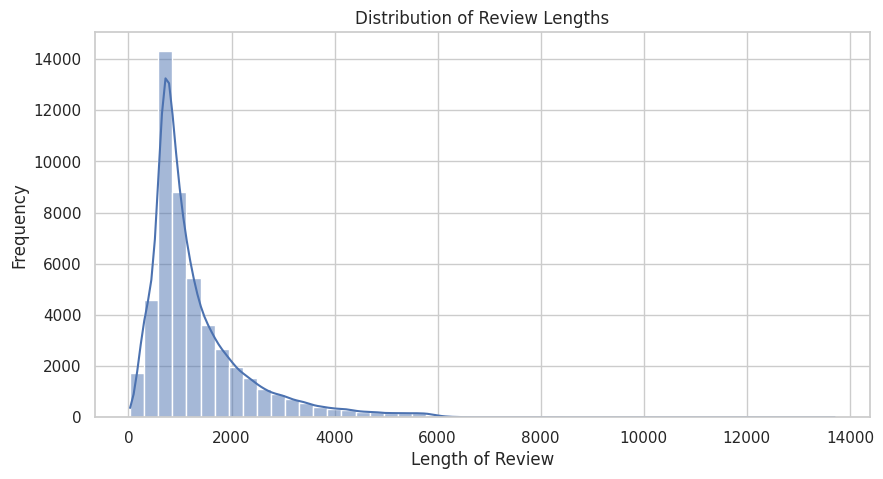


Example positive review
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ...

Example negative review:
Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This movie is slower than a soap opera... and suddenly, Jake decides to become Rambo and kill the zombie.<br /><br />OK, first of all when you're going to make a film you must Decide if its a thriller or a drama! As a drama the movie is watchable. Parents are divorcing & arguing like in real life. And

In [23]:
if df is not None and 'review' in df.columns:
    print("\nAnalysis of 'review' column:")
    # Calculate review length
    df['review_length'] = df['review'].apply(len)
    
    print('Basic statistics for review length:')
    print(df['review_length'].describe())
    
    # Plot distribution of review lengths
    plt.figure(figsize=(10, 5))
    sns.histplot(df['review_length'], bins=50, kde=True)
    plt.title('Distribution of Review Lengths')
    plt.xlabel('Length of Review')
    plt.ylabel('Frequency')
    plt.show()

    # Display some example reviews
    print('\nExample positive review')
    try:
        print(df[df['sentiment'] == 'positive']['review'].iloc[0][:500] + '...')
    except Exception:
        print("No positive reviews found.")

    
    print("\nExample negative review:")
    try:
        print(df[df['sentiment']=='negative']['review'].iloc[0][:500]+ '...')
    except Exception:
        print("No negative reviews found.")
elif df is not None:
    print("\n'review' column not found in the dataset.")